# Complexity of Quantum Annealing on 1D Ising

#### Imports

In [68]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule
from ManyBodyQutip.qutip_class import SpinOperator 
from src.utils import Sector

## Initialization of the target Hamiltonian

#### Hyperapameters

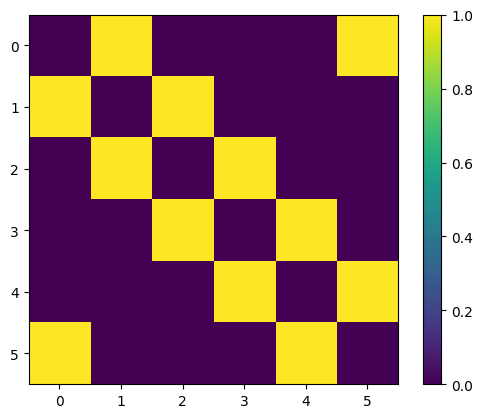

In [70]:
#### create istances on networkx
nqubits = 6

basis=computational_basis(nqubits)
    
jij = np.roll(np.eye(nqubits),axis=1,shift=1)+np.roll(np.eye(nqubits),axis=1,shift=-1)

plt.imshow(jij)
plt.colorbar()
plt.show()

#### Hamiltonian Initialization

In [71]:
nqubits=jij.shape[0]

PS=Sector(nqubits=nqubits)

target_hamiltonian=get_longitudinal_hamiltonian(jij)
target_hamiltonian_s=PS.project(target_hamiltonian)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)

driver_hamiltonian_s=PS.project(driver_hamiltonian)


Sector: 32 states out of 64


#### Analysis of the spectrum of the target hamiltonian

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


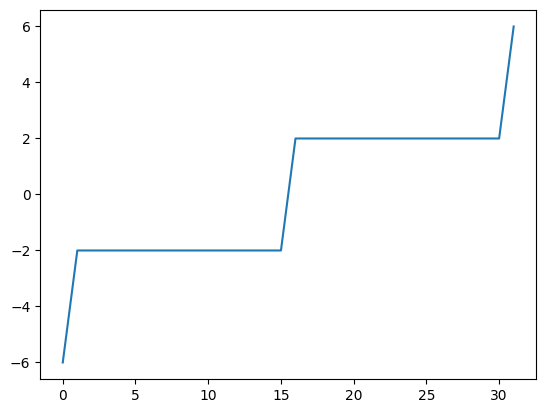

(-6+0j) (-2+0j) [0 1 0 1 0 1] [0 0 1 0 0 1]


In [72]:
values=target_hamiltonian_s.diagonal()

spectrum_target_hamiltonian_s=np.sort(values)
eigenstates_target_hamiltonian_s=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian_s)
plt.show()

print(spectrum_target_hamiltonian_s[0],spectrum_target_hamiltonian_s[1],eigenstates_target_hamiltonian_s[0],eigenstates_target_hamiltonian_s[1])

#### Time evolution

In [73]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 10
time_steps = int(10 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [74]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)
print(psi_init.shape)
# ── initialization ────────────────────────────────────────────────────────────
spectrum            = np.zeros((time_steps, nlevels))
energy              = np.zeros(time_steps)
probabilities       = np.zeros((time_steps, nlevels))
psi_history          = np.zeros((time_steps, dim//2), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim//2, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (t / tau) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)


    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(hamiltonian_t.astype(complex), which='SA', k=nlevels)
    order              = np.argsort(spectrum_t)
    spectrum[i]        = spectrum_t[order]
    eigenstates_raw    = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1,0])
print(spectrum.shape)
print(time[np.argmin(spectrum[:,2]-spectrum[:,0])],np.min(spectrum[:,2]-spectrum[:,0]))

min_time_gap= time[np.argmin(spectrum[:,2]-spectrum[:,0])]

(32,)


/tmp/ipykernel_31887/2634436619.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()


0.8440423417925212
(100, 10)
3.8383838383838382 1.2042511286833912


Check the results

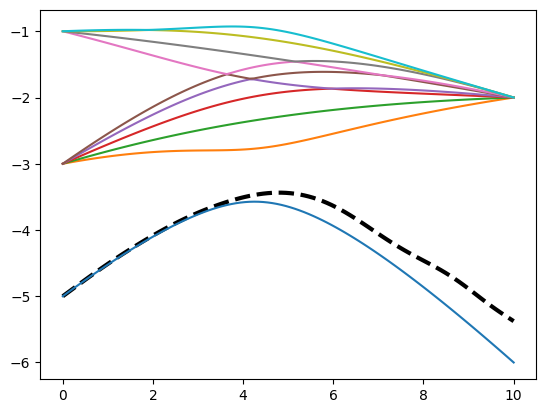

In [75]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
        plt.plot(time,spectrum[:,i])

plt.show()

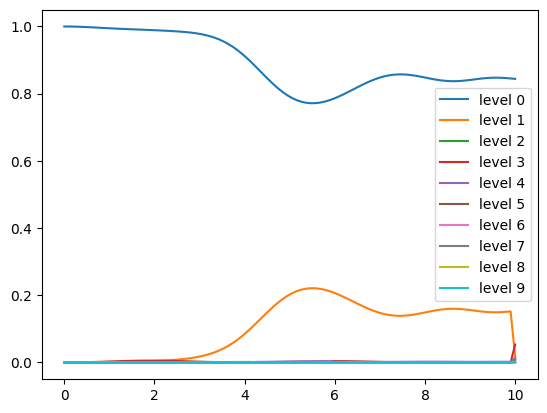

In [76]:
for i in range(nlevels):
    plt.plot(time,probabilities[:,i],label=f'level {i}')

plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [77]:
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits//2)

# single state
magic=[]
magic_gs_level=[]
entanglememt_entropy_history=[]
entanglement_entropy_gs_level_history=[]
for i in trange(time_steps):
    state=psi_history[i]
    magic.append(sre(PS.lift(state)))
    magic_gs_level.append(sre(PS.lift(eigenstates_history[i,:,0])))
    entanglememt_entropy_history.append(entanglement_entropy.von_neumann(PS.lift(state)))
    entanglement_entropy_gs_level_history.append(entanglement_entropy.von_neumann(PS.lift(eigenstates_history[i,:,0])))


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli tables for n=6 (4096 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=3 qubits (8d)


100%|██████████| 100/100 [00:00<00:00, 291.38it/s]


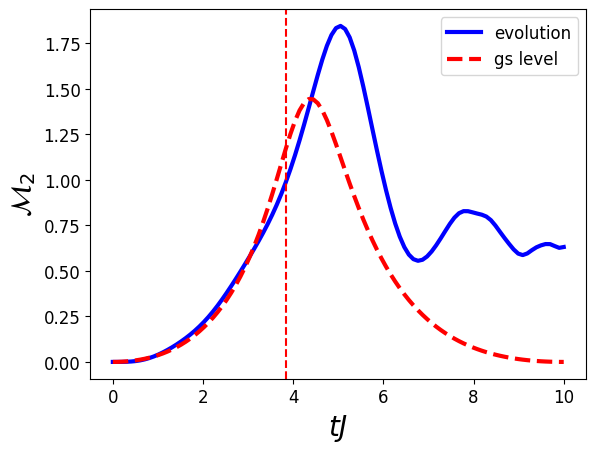

In [78]:
plt.plot(time,magic,label='evolution',color='blue',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='gs level',color='red',linestyle='--',linewidth=3)
plt.axvline(min_time_gap,linestyle='--',color='red')
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

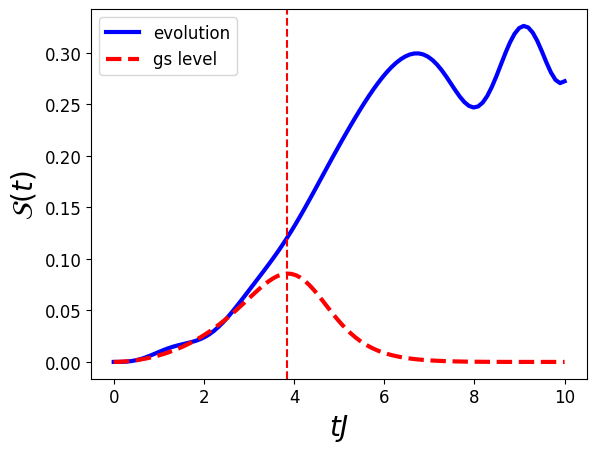

In [79]:
plt.plot(time,entanglememt_entropy_history,label='evolution',color='blue',linestyle='-',linewidth=3)
plt.plot(time,entanglement_entropy_gs_level_history,label='gs level',color='red',linestyle='--',linewidth=3)
plt.axvline(min_time_gap,linestyle='--',color='red')
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{S}(t)$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

In [80]:

from curses.ascii import SP


_,eigenstates_target_hamiltonian=eigsh(target_hamiltonian_s.astype(complex), which='SA', k=4)
print(sre(PS.lift(eigenstates_target_hamiltonian[:,0]))) 

-8.881784197001252e-16


## Optimal Control Method

##### Get Hyperparameters

In [81]:
number_parameters=5
type='F-CRAB'

In [ ]:
from scipy.optimize import minimize

model=SchedulerModel(target_hamiltonian=target_hamiltonian_s,initial_hamiltonian=driver_hamiltonian_s,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian_s,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

#### Jax optimization (optional)

In [97]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode='annealing ansatz',
    random=False,
)

trainer = JaxTrainer(model, maxiter=500, tol=1e-3, ftol=1e-5, gtol=1e-4, verbose=True)
results = trainer.run()

h_driver  = results['h_driver']
h_target  = results['h_target']
psi_final = results['psi']
energy    = results['energy']   # already in physical units

JIT compilation done.
-5.638554134110622
-5.868629542332694
-5.901249305066409
-5.932336799458363
-5.937386868084774
-5.941000392796841
-5.942669855301495
-5.950686059656558
-5.9556378839224235
-5.957363411440116
-5.959889241136505
-5.961600333956313
-5.966988335140868
-5.971266262435625
-5.973316395973232
-5.979007644505649
-5.981522196463612
-5.983242334523447
-5.984425147402059
-5.985332788458887
-5.98690226858165
-5.988606919383887
-5.9891476544202655
-5.989816104711505
-5.98995933032547
-5.990305270894918
-5.991249894662778
-5.99189546633249
-5.992614044468708
-5.99303239866968
-5.993124186037193
-5.993192190616129
-5.993322241275627
-5.993368924308391

Optimization success : True
Final energy         : -5.993369
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


#### Check the results

(2.2064462015368695+3.5678427904947094j)


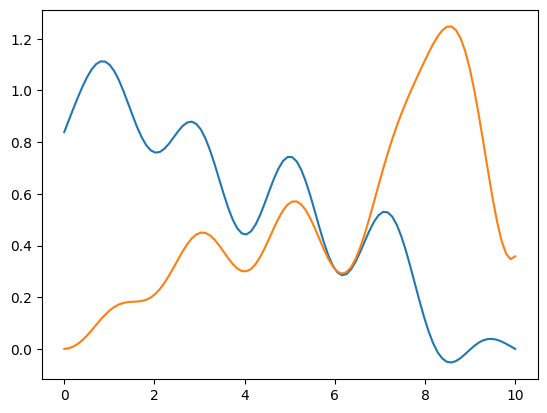

(-5.993368924308384+0j)


In [98]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian_s.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0]*driver_hamiltonian_s.dot(psi_init)))

plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()





# initialization
psi=psi_init.copy()
psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i,t in enumerate(time):
    
    hamiltonian_t=h_driver[i]*driver_hamiltonian_s+target_hamiltonian_s*h_target[i]
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    psi_history_optimalcontrol[i]=psi
    #for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

In [99]:


# initialization
energy_optimal=np.zeros(time_steps)
probabilities_optimalcontrol=np.zeros((time_steps,nlevels))
spectrum_optimalcontrol=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_optimalcontrol[i]     
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i]=spectrum_t
    # overlap
    probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_optimalcontrol[-1,0])

/tmp/ipykernel_31887/2306226813.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_31887/2306226813.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))


10.0
(-5.993368924308384+0j)
0.9983426182637342


In [100]:
print(spectrum_optimalcontrol[-1])

[-6. -2. -2. -2. -2. -2. -2. -2. -2. -2.]


0
-5.999999999999999
1
-2.000000000000001
2
-2.0
3
-2.0
4
-2.0
5
-2.0
6
-2.0
7
-2.0
8
-1.9999999999999993
9
-1.9999999999999991


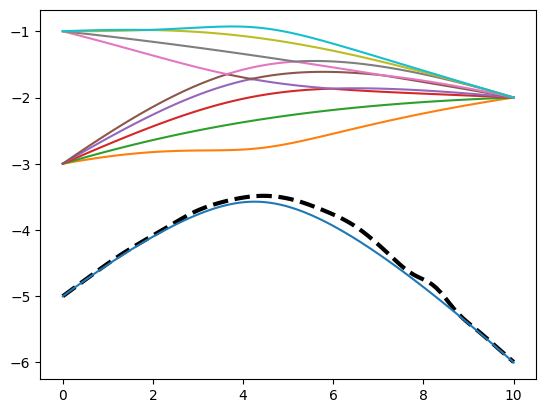

In [101]:

plt.plot(time,energy_optimal,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
        print(i)
        print(spectrum_optimalcontrol[-1,i])
        plt.plot(time,spectrum_optimalcontrol[:,i])

plt.show()

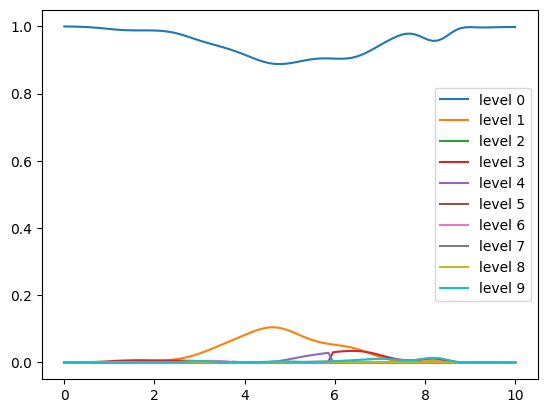

In [102]:
for i in range(nlevels):
    plt.plot(time,probabilities_optimalcontrol[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [103]:
# single state
magic_optimal_control=[]
entanglememt_entropy_history_optimal_control=[]
for i in trange(time_steps):
    state=psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre(PS.lift(state)))
    entanglememt_entropy_history_optimal_control.append(entanglement_entropy.von_neumann(PS.lift(state)))


100%|██████████| 100/100 [00:00<00:00, 750.02it/s]


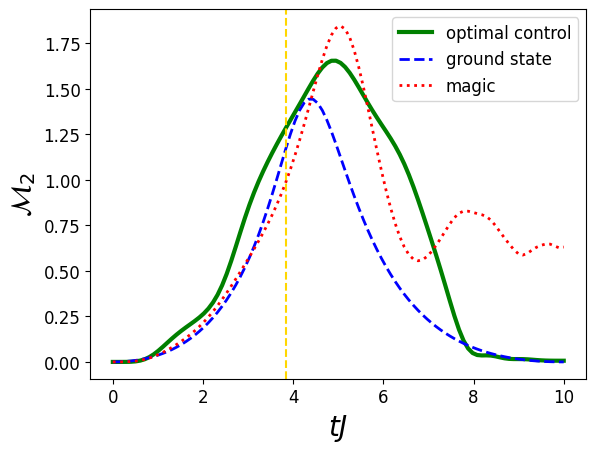

In [104]:
plt.plot(time,magic_optimal_control,label='optimal control',color='green',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='ground state',color='blue',linestyle='--',linewidth=2)
plt.plot(time,magic,label='magic',color='red',linestyle=':',linewidth=2)
plt.axvline(min_time_gap,linestyle='--',color='gold')
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

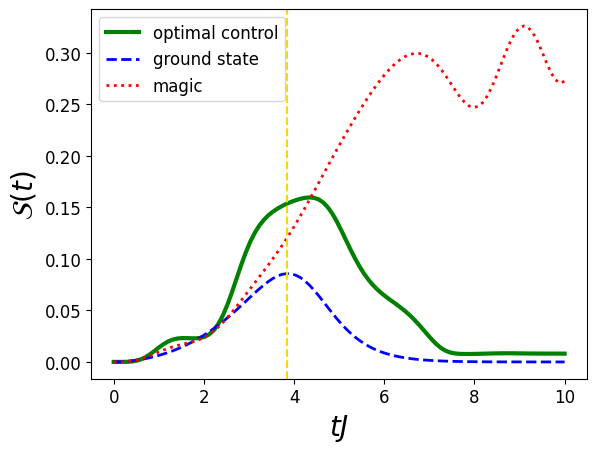

In [105]:
plt.plot(time,entanglememt_entropy_history_optimal_control,label='optimal control',color='green',linestyle='-',linewidth=3)
plt.plot(time,entanglement_entropy_gs_level_history,label='ground state',color='blue',linestyle='--',linewidth=2)
plt.plot(time,entanglememt_entropy_history,label='magic',color='red',linestyle=':',linewidth=2)
plt.axvline(min_time_gap,linestyle='--',color='gold')
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{S}(t)$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

##### Energy Path and NON-STABILIZERNESS through the optimization

[-5.638554134110622, -5.868629542332694, -5.901249305066409, -5.932336799458363, -5.937386868084774, -5.941000392796841, -5.942669855301495, -5.950686059656558, -5.9556378839224235, -5.957363411440116, -5.959889241136505, -5.961600333956313, -5.966988335140868, -5.971266262435625, -5.973316395973232, -5.979007644505649, -5.981522196463612, -5.983242334523447, -5.984425147402059, -5.985332788458887, -5.98690226858165, -5.988606919383887, -5.9891476544202655, -5.989816104711505, -5.98995933032547, -5.990305270894918, -5.991249894662778, -5.99189546633249, -5.992614044468708, -5.99303239866968, -5.993124186037193, -5.993192190616129, -5.993322241275627, -5.993368924308391]


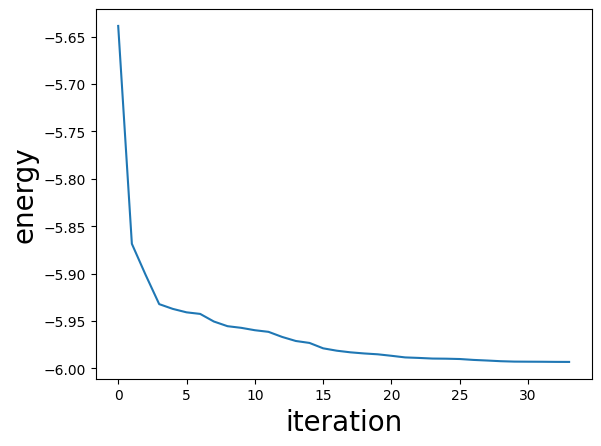

34
(100,)


In [106]:
print(model.history)
plt.plot(np.arange(len(model.history)),model.history)
plt.xlabel('iteration',fontsize=20)
plt.ylabel('energy',fontsize=20)
#plt.yscale('log')
plt.show()
print(len(model.history))


print(model.history_drivings[0][0].shape)

In [116]:
total_magic=[]
total_entanglement=[]
delta_t=model.tf/model.nsteps
print(len(model.history_drivings[0]))
for i in trange(0,  len(model.history_drivings),1):

        
    h_driver, h_target = model.history_drivings[i]

    # initialization
    psi=psi_init.copy()
    psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
    magic=[]
    entanglement=[]
    for i,t in enumerate(time):
        hamiltonian_t=h_driver[i]*driver_hamiltonian_s+target_hamiltonian_s*h_target[i]
        psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
        psi_history_optimalcontrol[i]=psi
        magic.append(sre(PS.lift(psi)))
        entanglement.append(entanglement_entropy.von_neumann(PS.lift(psi)))
    total_magic.append(delta_t*np.sum(magic))
    total_entanglement.append(delta_t*np.sum(entanglement))


2


100%|██████████| 34/34 [00:06<00:00,  5.09it/s]


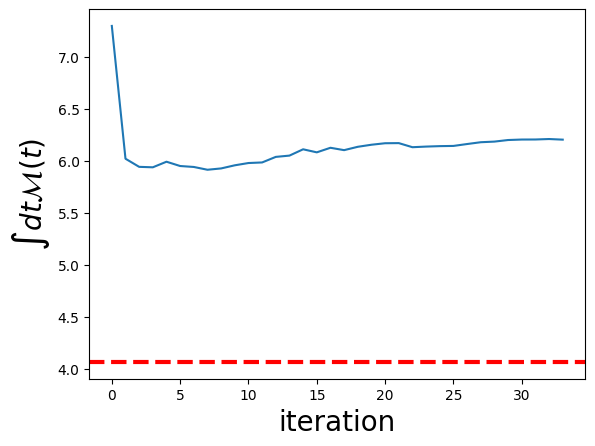

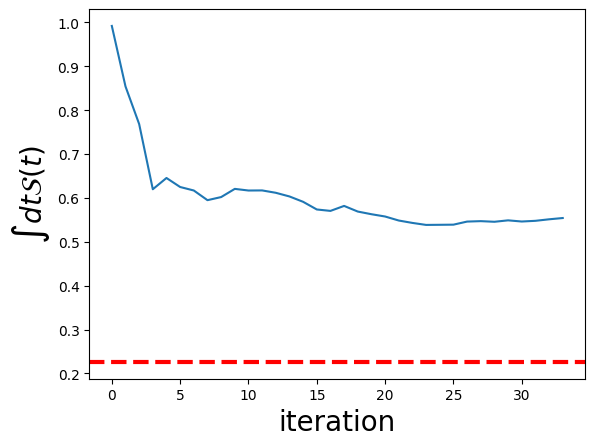

In [120]:
plt.plot(np.arange(len(total_magic)),total_magic)
plt.axhline(delta_t*np.sum(magic_gs_level),color='red',linestyle='--',linewidth=3,label='gs level')
plt.xlabel('iteration',fontsize=20)
plt.ylabel(r'$\int dt  \mathcal{M}(t) $',fontsize=20)
plt.show()


plt.plot(np.arange(len(total_entanglement)),total_entanglement)
plt.axhline(delta_t*np.sum(entanglement_entropy_gs_level_history),color='red',linestyle='--',linewidth=3,label='gs level')
plt.xlabel('iteration',fontsize=20)
plt.ylabel(r'$\int dt  \mathcal{S}(t) $',fontsize=20)
plt.show()


## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [45]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
counteradiabatic_term_s=PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 192 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	4j
  (0, 2)	4j
  (0, 4)	4j
  (0, 8)	4j
  (0, 16)	4j
  (0, 32)	4j
  (1, 0)	(-0-4j)
  (1, 5)	4j
  (1, 9)	4j
  (1, 17)	4j
  (2, 0)	(-0-4j)
  (2, 10)	4j
  (2, 18)	4j
  (2, 34)	4j
  (3, 11)	4j
  (3, 19)	4j
  (4, 0)	(-0-4j)
  (4, 5)	4j
  (4, 20)	4j
  (4, 36)	4j
  (5, 1)	(-0-4j)
  (5, 4)	(-0-4j)
  (5, 7)	(-0-4j)
  (5, 21)	4j
  (6, 22)	4j
  :	:
  (57, 41)	4j
  (58, 42)	4j
  (58, 56)	(-0-4j)
  (58, 59)	(-0-4j)
  (58, 62)	(-0-4j)
  (59, 27)	4j
  (59, 43)	4j
  (59, 58)	4j
  (59, 63)	(-0-4j)
  (60, 44)	4j
  (60, 52)	4j
  (61, 29)	4j
  (61, 45)	4j
  (61, 53)	4j
  (61, 63)	(-0-4j)
  (62, 46)	4j
  (62, 54)	4j
  (62, 58)	4j
  (62, 63)	(-0-4j)
  (63, 31)	4j
  (63, 47)	4j
  (63, 55)	4j
  (63, 59)	4j
  (63, 61)	4j
  (63, 62)	4j


Compute the optimal driving of the adiabatic gauge potential from calculations

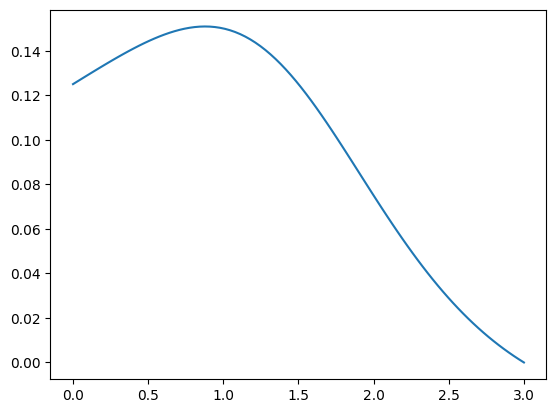

In [29]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2       = np.sum(J ** 2)                          # ||J||^2
    J2_row   = np.sum(J ** 2, axis=1)                  # (n,): sum_B J_AB^2
    J4_sum   = np.sum(J2_row ** 2)                     # sum_A (sum_B J_AB^2)^2

    numerator   = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam)**2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator

# schedule of alpha_0 along the annealing
alpha = -1*np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time,alpha)
plt.show()

In [30]:
from scipy.sparse.linalg import eigsh,expm_multiply
from src.annealing_utils import compute_exact_AGP
# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)

# initialization

psi=psi_init.copy()
psi_history_counteradiabatic=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic=np.zeros((time_steps,nlevels))
energy_counteradiabatic=np.zeros(time_steps)
for i,t in enumerate(time):
    exact_AGP=compute_exact_AGP(driver_hamiltonian=driver_hamiltonian_s,target_hamiltonian=target_hamiltonian_s,lam=t/tau,n_eigs=2)
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau+(1/tau)*exact_AGP
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_counteradiabatic[i]=spectrum_t
    energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i]=psi


/tmp/ipykernel_1274/3044621191.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [33]:

# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian=np.zeros(time_steps)
probabilities_counteradiabatic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_counteradiabatic[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()

    energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1,0])

/tmp/ipykernel_1274/1932926314.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_1274/1932926314.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


3.0
(-5.572732042238597+0j)
-5.572732042238597
0.9010092674360807


##### Results of the unbiased counteradiabatic term

0
-6.000000000000002
-5.572732042238597
1
-2.0
-5.572732042238597
2
-2.0
-5.572732042238597
3
-2.0
-5.572732042238597
4
-2.0
-5.572732042238597
5
-1.9999999999999998
-5.572732042238597
6
-1.9999999999999998
-5.572732042238597
7
-1.9999999999999996
-5.572732042238597
8
-1.9999999999999987
-5.572732042238597
9
-1.9999999999999964
-5.572732042238597


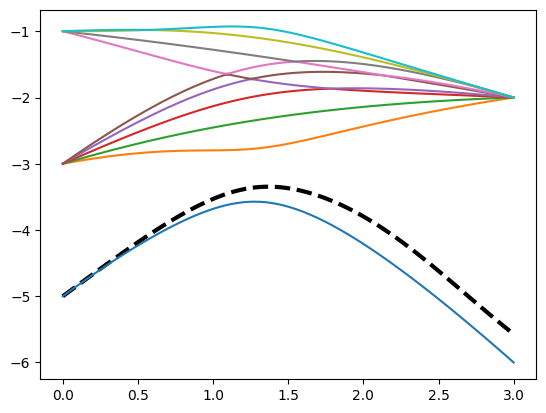

0
-6.000530259931216
1
-2.0000000000000027
2
-2.0000000000000018
3
-2.0000000000000013
4
-2.000000000000001
5
-2.000000000000001
6
-2.0
7
-2.0
8
-1.9999999999999998
9
-1.9999999999999998


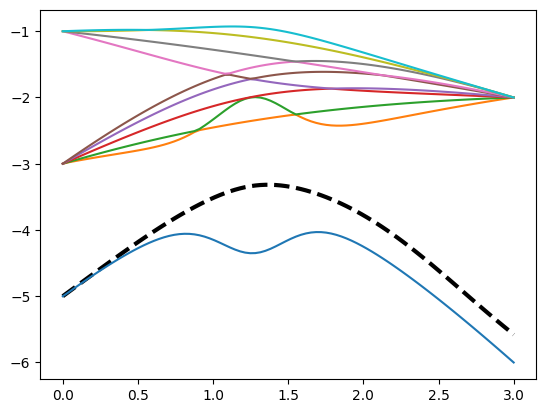

In [34]:

plt.plot(time,energy_counteradiabatic_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):        
        print(i)
        print(spectrum[-1,i])
        print(energy_counteradiabatic_linear_hamiltonian[-1])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_counteradiabatic,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

        print(i)
        print(spectrum_counteradiabatic[-1,i])
        plt.plot(time,spectrum_counteradiabatic[:,i])

plt.show()


In [31]:
for i in range(nlevels):
    plt.plot(time,probabilities_counteradiabatic[:,i],label=f'level {i}')

plt.legend()
plt.show()

NameError: name 'probabilities_counteradiabatic' is not defined

##### Measure of Stabilizerness

In [51]:
# single state
magic_counteradiabatic=[]

for i in trange(time_steps):
    state=psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))


100%|██████████| 90/90 [00:00<00:00, 816.60it/s]


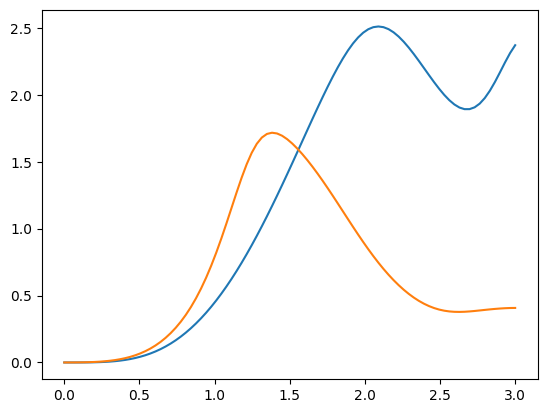

In [52]:
plt.plot(time,magic)
#plt.plot(time,magic_optimal_control)
plt.plot(time,magic_counteradiabatic)
plt.show()

## Non-stoquastic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [176]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

js=np.random.choice([-1,1],size=(nqubits,nqubits))

nonstoquastic_driving=0.
for i in range(nqubits):
    #nonstoquastic_driving+=SpinOperator(index=[('x',i)],coupling=[(-1)**(i)],size=nqubits).qutip_op.data_as('csr_matrix')
    for j in range(i+1,nqubits):
        nonstoquastic_driving+=SpinOperator(index=[('x',i,'x',j)],coupling=[(-1)],size=nqubits).qutip_op.data_as('csr_matrix')
        #nonstoquastic_driving+=SpinOperator(index=[('y',i,'y',j)],coupling=[(0.5)],size=nqubits).qutip_op.data_as('csr_matrix')
        
nonstoquastic_driving_s=PS.project(nonstoquastic_driving)

In [177]:
from scipy.sparse.linalg import eigsh,expm_multiply

# combined driver: H_D + beta * H_NS
beta           = 1
total_driver_ns    = (driver_hamiltonian_s )


print(total_driver_ns)
_,eigvecs=eigsh(total_driver_ns.astype(complex), which='SA', k=2)
psi_init = eigvecs[:, 0].astype(complex)

#psi_init       = np.ones(total_driver_ns.shape[0], dtype=complex) / np.sqrt(total_driver_ns.shape[0])
e_check        = (psi_init.conj() @ total_driver_ns @ psi_init).real
print(f'GS energy check: {e_check:.6f}')   # should match evals[0]

# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    psi_history_catalyst[i]=psi
    hamiltonian_t=(1-t/tau)*total_driver_ns+target_hamiltonian_s*t/tau+(1-t/tau)*(t/tau)*nonstoquastic_driving_s
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    


<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 896 stored elements and shape (128, 128)>
  Coords	Values
  (0, 1)	(-1+0j)
  (0, 2)	(-1+0j)
  (0, 4)	(-1+0j)
  (0, 8)	(-1+0j)
  (0, 16)	(-1+0j)
  (0, 32)	(-1+0j)
  (0, 64)	(-1+0j)
  (1, 0)	(-1+0j)
  (1, 3)	(-1+0j)
  (1, 5)	(-1+0j)
  (1, 9)	(-1+0j)
  (1, 17)	(-1+0j)
  (1, 33)	(-1+0j)
  (1, 65)	(-1+0j)
  (2, 0)	(-1+0j)
  (2, 3)	(-1+0j)
  (2, 6)	(-1+0j)
  (2, 10)	(-1+0j)
  (2, 18)	(-1+0j)
  (2, 34)	(-1+0j)
  (2, 66)	(-1+0j)
  (3, 1)	(-1+0j)
  (3, 2)	(-1+0j)
  (3, 7)	(-1+0j)
  (3, 11)	(-1+0j)
  :	:
  (124, 116)	(-1+0j)
  (124, 120)	(-1+0j)
  (124, 125)	(-1+0j)
  (124, 126)	(-1+0j)
  (125, 61)	(-1+0j)
  (125, 93)	(-1+0j)
  (125, 109)	(-1+0j)
  (125, 117)	(-1+0j)
  (125, 121)	(-1+0j)
  (125, 124)	(-1+0j)
  (125, 127)	(-1+0j)
  (126, 62)	(-1+0j)
  (126, 94)	(-1+0j)
  (126, 110)	(-1+0j)
  (126, 118)	(-1+0j)
  (126, 122)	(-1+0j)
  (126, 124)	(-1+0j)
  (126, 127)	(-1+0j)
  (127, 63)	(-1+0j)
  (127, 95)	(-1+0j)
  (127, 111)	(-1+0j)


/tmp/ipykernel_1274/3895158686.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [178]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_nonstoquastic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*total_driver_ns+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_nonstoquastic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_nonstoquastic[-1,0])

/tmp/ipykernel_1274/2405594016.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_nonstoquastic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_1274/2405594016.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


10.0
(-6.557041895162461+0j)
0.6406250778200623


##### Results of the unbiased catalyst

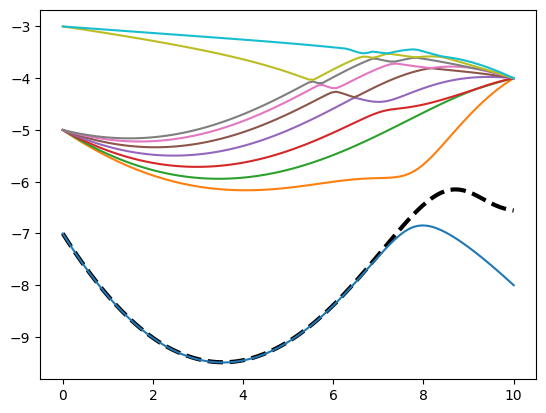

In [179]:

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):

        plt.plot(time,spectrum_catalyst[:,i])

plt.show()



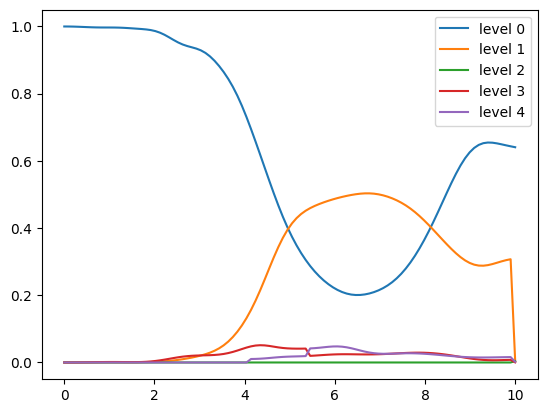

In [180]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_nonstoquastic[:,i],label=f'level {i}')

plt.legend()
plt.show()

In [142]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic_nonstoquastic=[]
for i in trange(time_steps):
    state=psi_history_catalyst[i]
    magic_nonstoquastic.append(sre(PS.lift(state)))
    

Building Pauli tables for n=6 (4096 Paulis)...
Done.


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 399.41it/s]


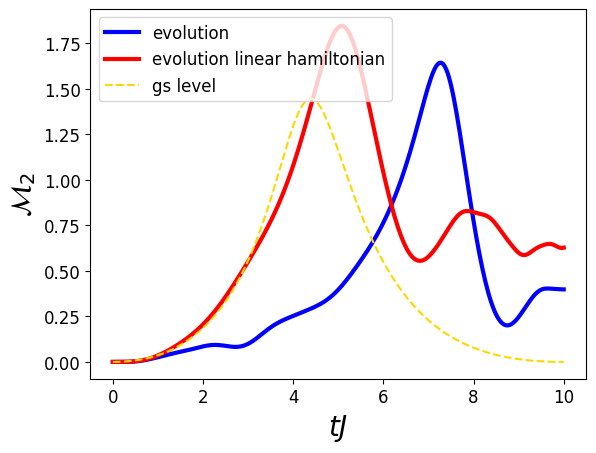

In [144]:
plt.plot(time,magic_nonstoquastic,label='evolution',color='blue',linestyle='-',linewidth=3)
plt.plot(time,magic,label='evolution linear hamiltonian',color='red',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='gs level',linestyle='--',color='gold')
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

## Quench Limit

In [48]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 10
time_steps = int(10 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [ ]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
_,eigvecs=eigsh(driver_hamiltonian_s, which='SA', k=2)
psi_init = eigvecs[:, 0].astype(complex)

# ── initialization ────────────────────────────────────────────────────────────
tau_q=0.1*tau
psi_history_quench          = np.zeros((time_steps, dim//2), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    psi_history_quench[i] = psi
    hamiltonian_t =  (t/tau)*target_hamiltonian_s+np.max((1-t/tau_q),0)*driver_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    


In [50]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits//2)
# single state
magic_quench=[]
entanglement_entropy_history_quench=[]
for i in trange(time_steps):
    state=psi_history_quench[i]
    magic_quench.append(sre(PS.lift(state)))
    entanglement_entropy_history_quench.append(entanglement_entropy.von_neumann(PS.lift(state)))

Building Pauli tables for n=8 (65536 Paulis)...
Done.
Bipartition: A=4 qubits (16d), B=4 qubits (16d)


100%|██████████| 100/100 [00:29<00:00,  3.35it/s]


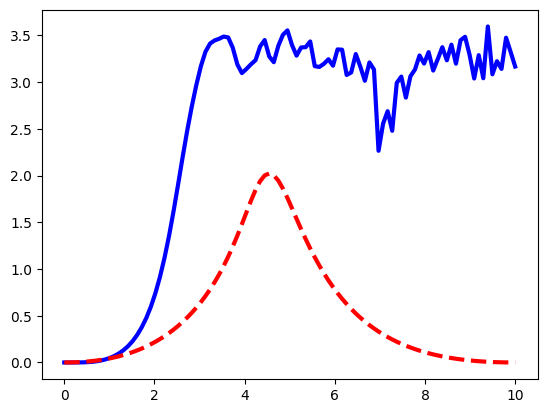

In [53]:
plt.plot(time,magic_quench,label='quench',color='blue',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='gs level',color='red',linestyle='--',linewidth=3)

plt.show()

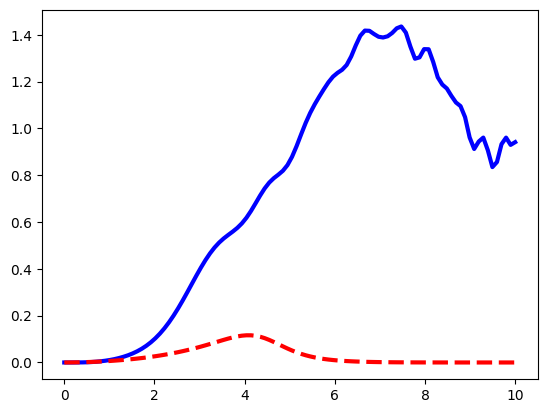

In [55]:
plt.plot(time,entanglement_entropy_history_quench,label='quench',color='blue',linestyle='-',linewidth=3)
plt.plot(time,entanglement_entropy_gs_level_history,label='gs level',color='red',linestyle='--',linewidth=3)

plt.show()

## Result analysis

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
tau=30
nqubits=6

data=np.load(f'magic_annealing_results_qubit_{nqubits}_tau_{tau:.1f}.npz')

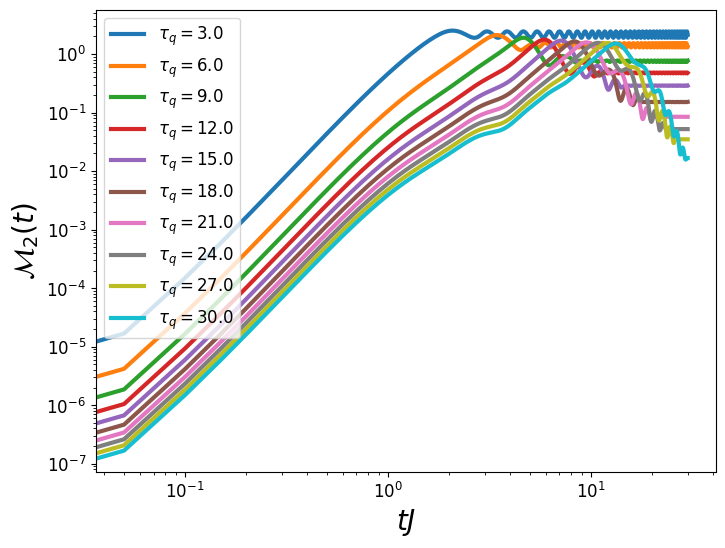

In [60]:
magic_list=data['magic_list']
magic_gs_level_list=data['magic_gs_level_list']
time=data['time']
tau_qs=data['tau_qs']
plt.figure(figsize=(8,6))
for i in range(len(magic_list)):
    plt.plot(time,magic_list[i],label=r'$\tau_q=$'+f'{tau_qs[i]:.1f}',linestyle='-',linewidth=3)
#plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2 (t)$',fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

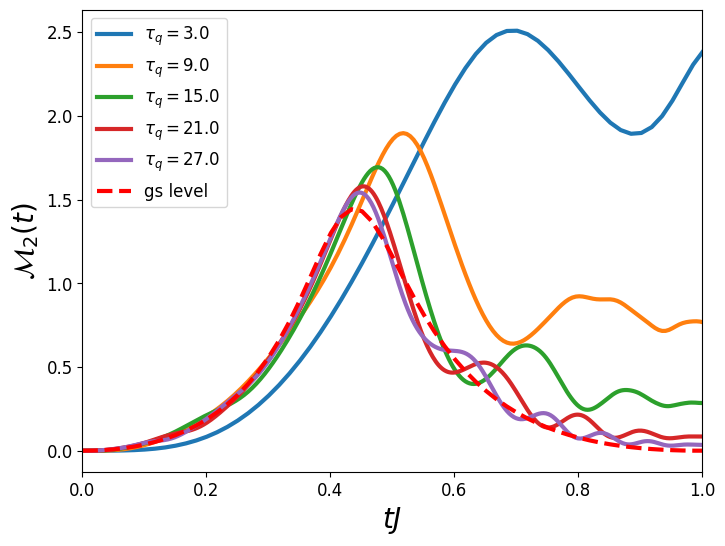

In [65]:
magic_list=data['magic_list']
magic_gs_level_list=data['magic_gs_level_list']
time=data['time']
tau_qs=data['tau_qs']
plt.figure(figsize=(8,6))
for i in range(0,len(magic_list),2):
    plt.plot(time/tau_qs[i],magic_list[i],label=r'$\tau_q=$'+f'{tau_qs[i]:.1f}',linestyle='-',linewidth=3)
plt.plot(time/tau_qs[0],magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlim(0,1)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2 (t)$',fontsize=20)
plt.legend(fontsize=12)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

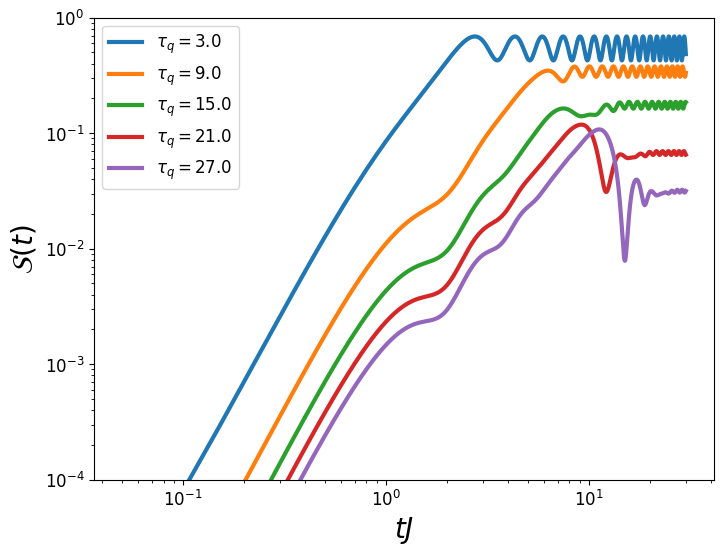

In [66]:
entanglement_entropy_history_list=data['entanglement_entropy_history_quench_list']
entanglement_entropy_gs_level_history=data['entanglement_entropy_gs_level_history_list']
time=data['time']
tau_qs=data['tau_qs']
plt.figure(figsize=(8,6))
for i in range(0,len(entanglement_entropy_history_list),2):
    plt.plot(time,entanglement_entropy_history_list[i],label=r'$\tau_q=$'+f'{tau_qs[i]:.1f}',linestyle='-',linewidth=3)
#plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{S} (t)$',fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim(10**-4,10**0)
plt.show()

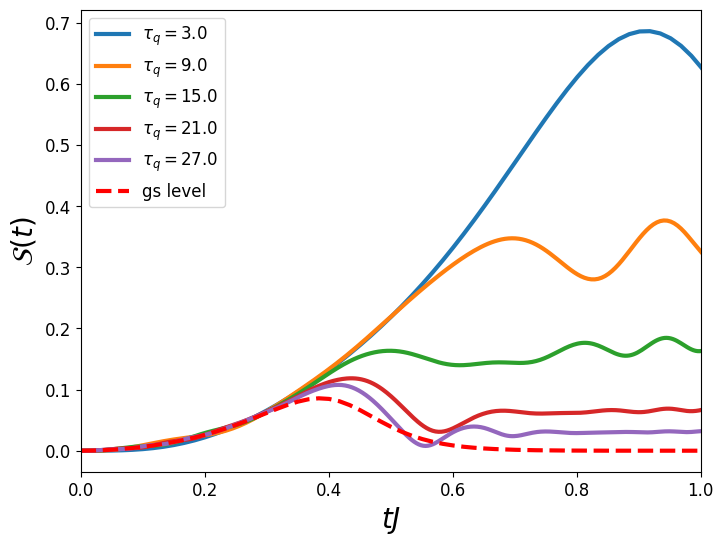

In [67]:

entanglement_entropy_gs_level_history=data['entanglement_entropy_gs_level_history_list']
time=data['time']
tau_qs=data['tau_qs']
plt.figure(figsize=(8,6))
for i in range(0,len(entanglement_entropy_history_list),2):
    plt.plot(time/tau_qs[i],entanglement_entropy_history_list[i],label=r'$\tau_q=$'+f'{tau_qs[i]:.1f}',linestyle='-',linewidth=3)
plt.plot(time/tau_qs[0],entanglement_entropy_gs_level_history[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlim(0,1)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{S} (t)$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()